In [1]:
import sys
sys.path.append('../src')
from utils.stock_simulation import Stock
from utils.report import fast_config
from utils.simulation import save_session, load_session
from utils.simulation.session import save_markets, load_markets

Markets loaded ← /Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/test/../src/utils/simulation/saved_markets.pkl


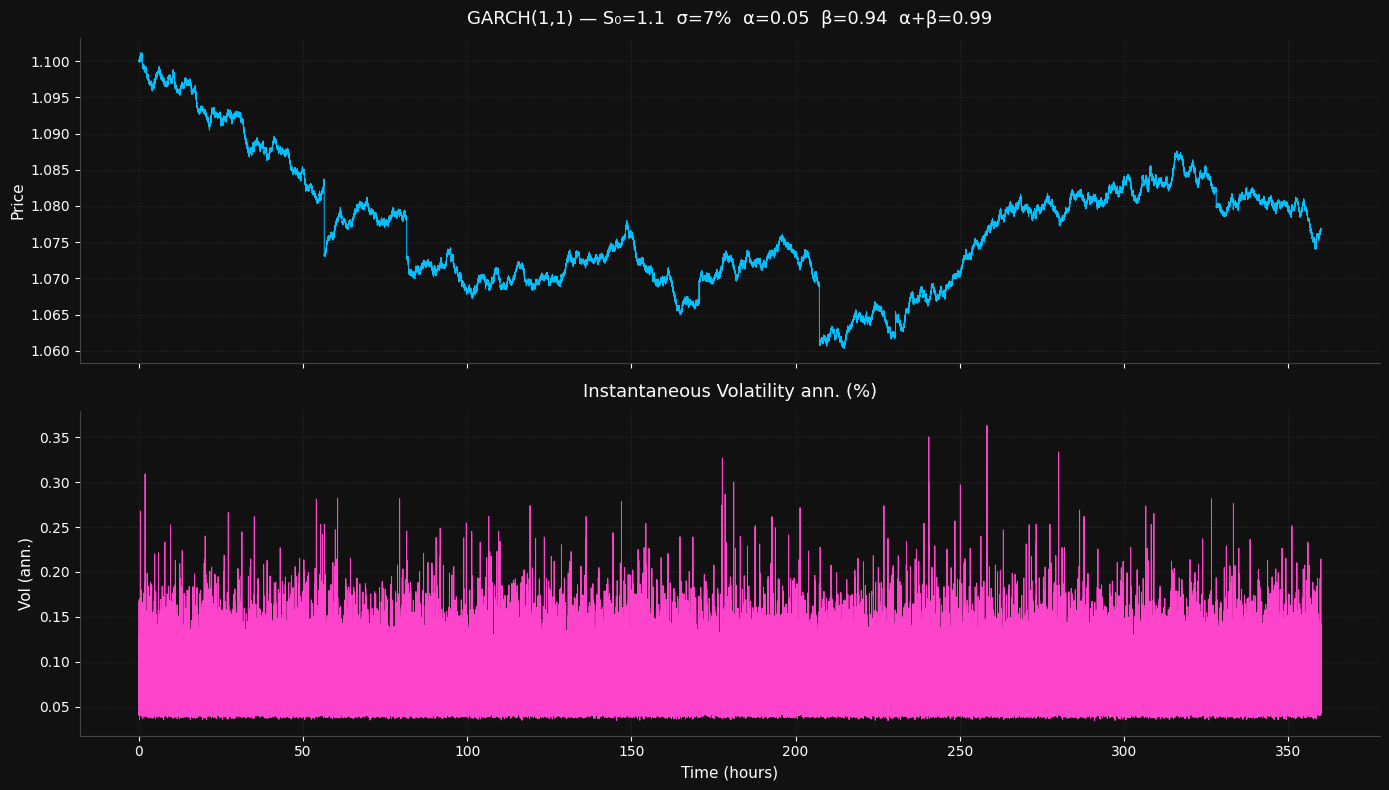

────────────────────────────────────────────────────────────────────────────
Metric                                               Skewed
────────────────────────────────────────────────────────────────────────────
Spread mean (price units)                            0.0002
Spread std  (price units)                            0.0000
Spread min  (price units)                            0.0002
Spread max  (price units)                            0.0002
Relative spread mean (%)                           0.0149%
Relative spread std  (%)                           0.0002%
Ask bias vs mid (mean)                               0.0001
Bid bias vs mid (mean)                               0.0001
Ask vol (ann., log-ret)                            9.0554%
Bid vol (ann., log-ret)                            9.0554%
Quote center offset (mean)                          -0.0000
Ask half − Bid half (mean)                          -0.0000
──────────────────────────────────────────────────────────────────────

In [2]:
# ── RUN ONCE to generate markets, then comment out ──────────────────────────
# Regenerate only when you want a new price path or spread shape.

# stock = Stock(drift=0.0, vol=0.07, origin=1.10)
# stock.simulate_garch(n_days=15, dt_seconds=0.05,
#                      alpha=0.05, beta=0.94,
#                      lam=100,       # 100 jumps/year ≈ 2/week  (was 300 = 1.2/day, too frequent)
#                      sigma_J=0.005) # ±0.5% per jump std ≈ 55 pips on EUR/USD
# market_B, market_C = fast_config.build_markets_B_C(stock)
# save_markets(stock, market_B, market_C)

# ── ALWAYS: load saved markets ───────────────────────────────────────────────
stock, market_B, market_C = load_markets()
stock.plot_vol_path()
#market_B.plot_noised_mid_price()
market_B.sanity_check_spreads()
#market_C.plot_noised_mid_price()
market_C.sanity_check_spreads()

In [3]:
# ── RUN EVERY TIME: rebuild MM + book + controller from current fast_config ──
# Changes to fast_config.py (gamma, delta_limit, ...) are picked up here.
market_maker, book = fast_config.build_market_maker_and_order_book(market_B, market_C)
controller = fast_config.build_controller(market_B, market_C, book, market_maker)

In [4]:
controller.simulate(limit = stock.n_steps)

100%|██████████| 25920000/25920000 [06:56<00:00, 62274.07it/s]


════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (15.0 days, dt=0.1s, 25,920,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                             +2313.34  USD
    Realized cash P&L                     +165013.47  USD
    Unrealized (open inventory × mid)      -162700.13  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                      +6070.93  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                 -1720.49  USD
    (mid drift on open EUR position)
  Total fees paid                            2037.10  USD
    Maker fees (exchange A)                  1811.95  USD
    Taker fees (hedge B/C)                    225.15  USD
────────────────────────────────────────────────────────────────────
  MM fills                                     6,142  (409/day)
  Hedge legs                                     

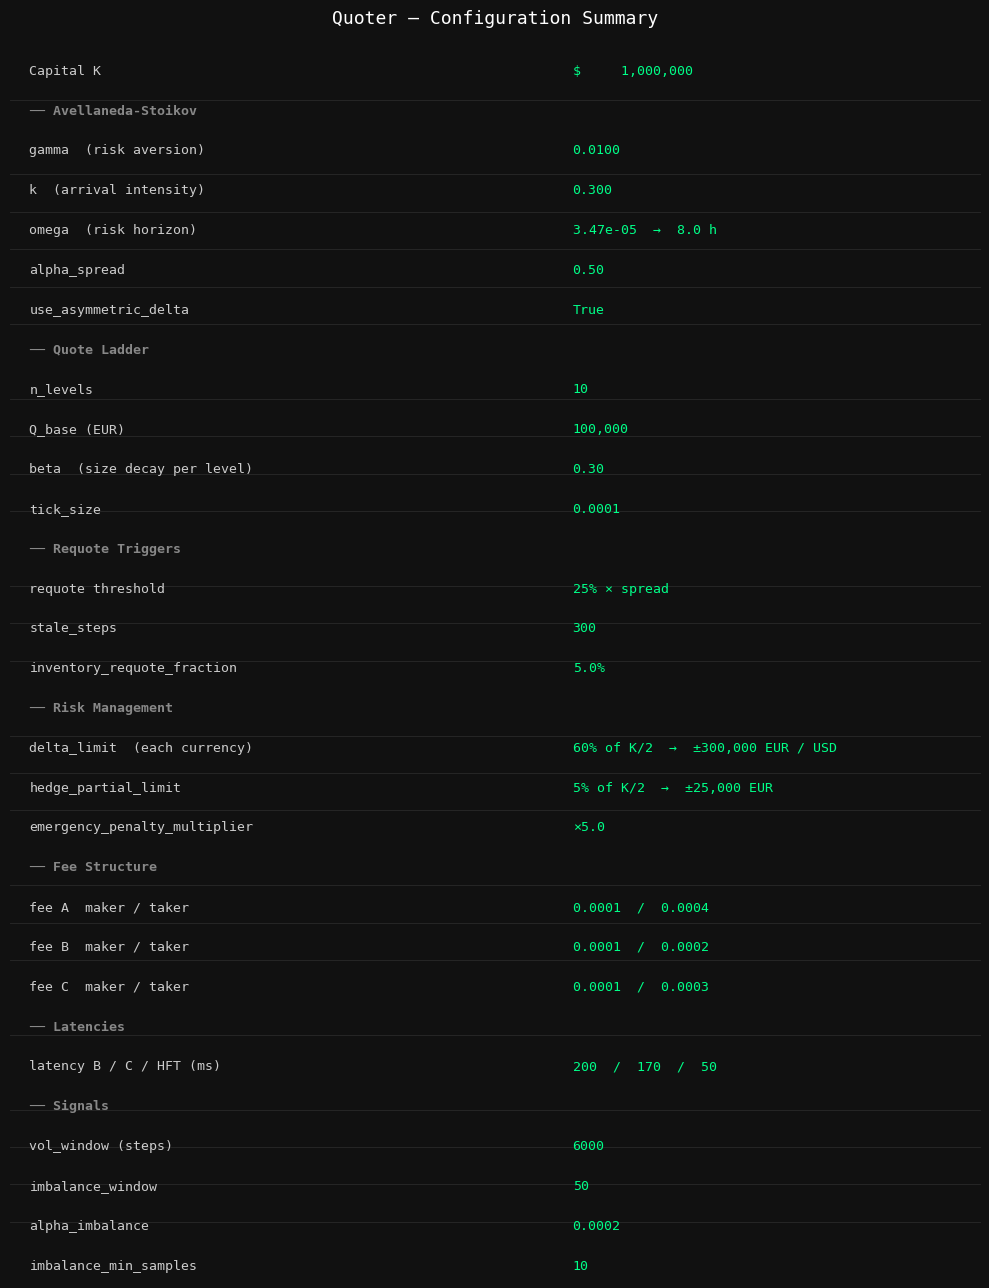

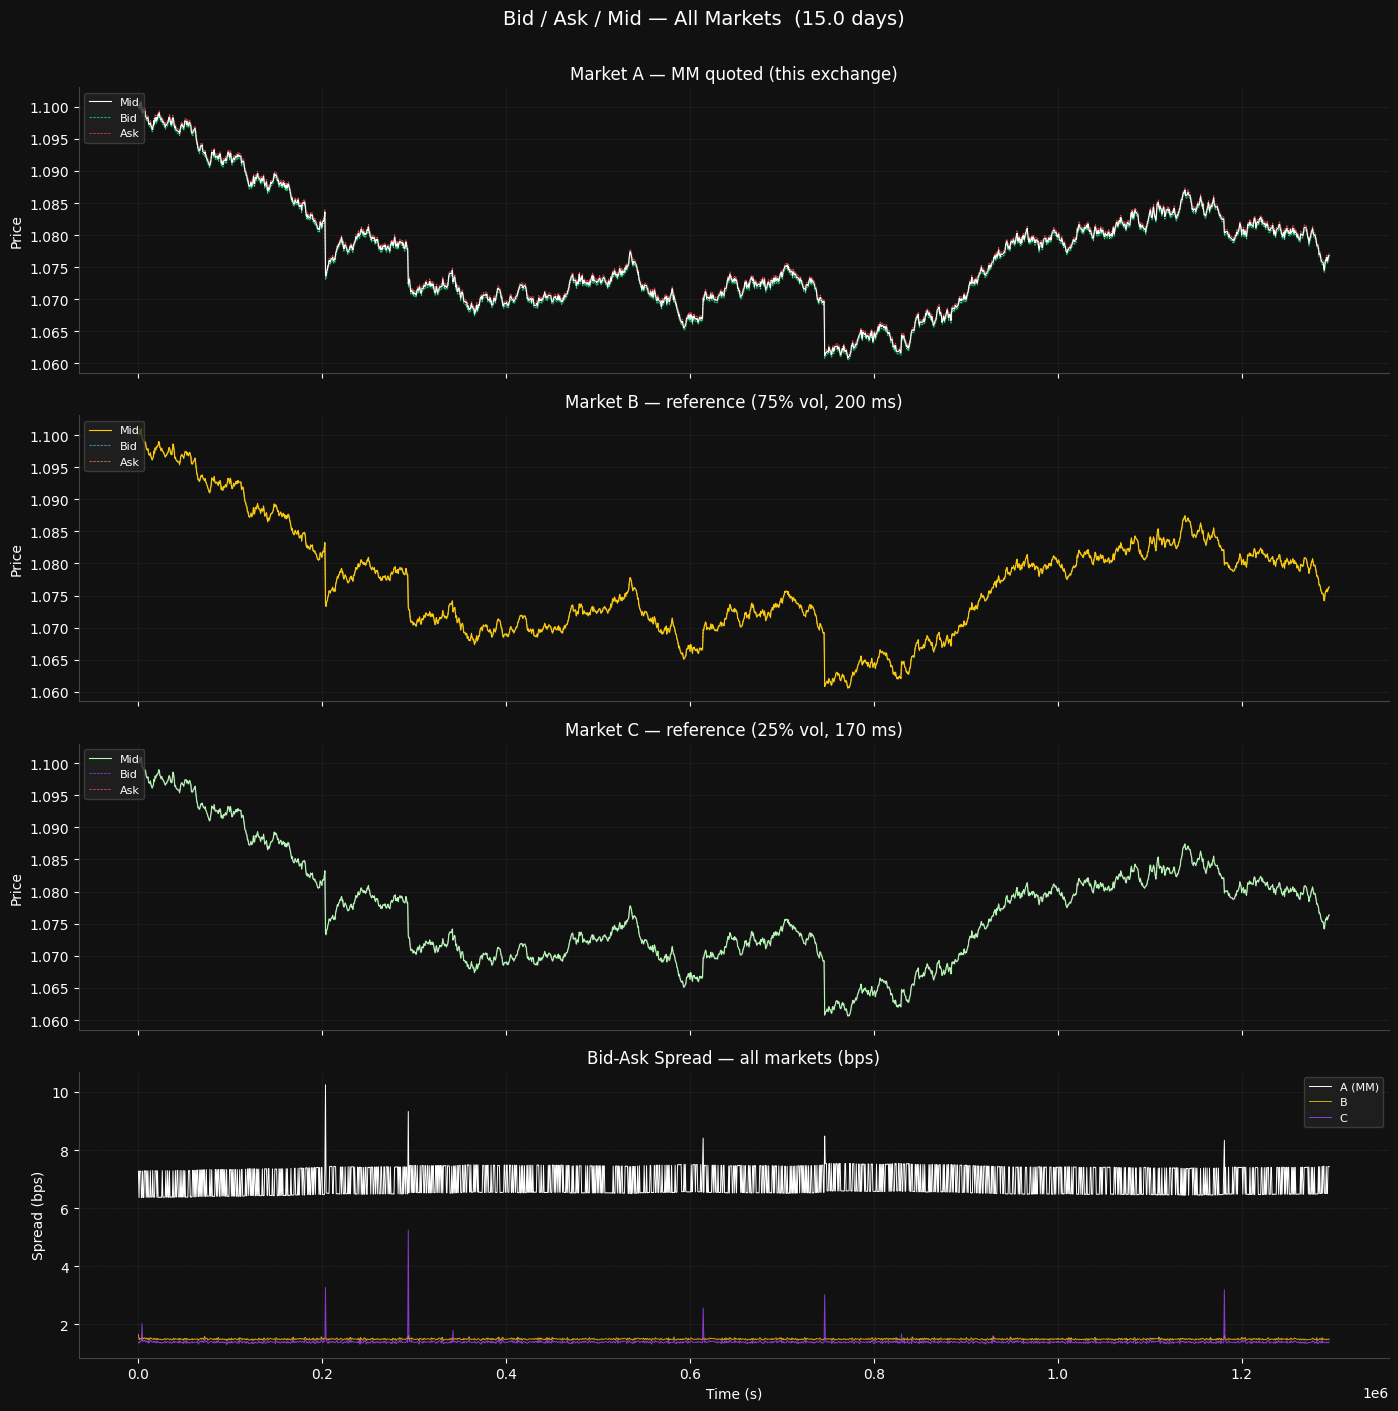

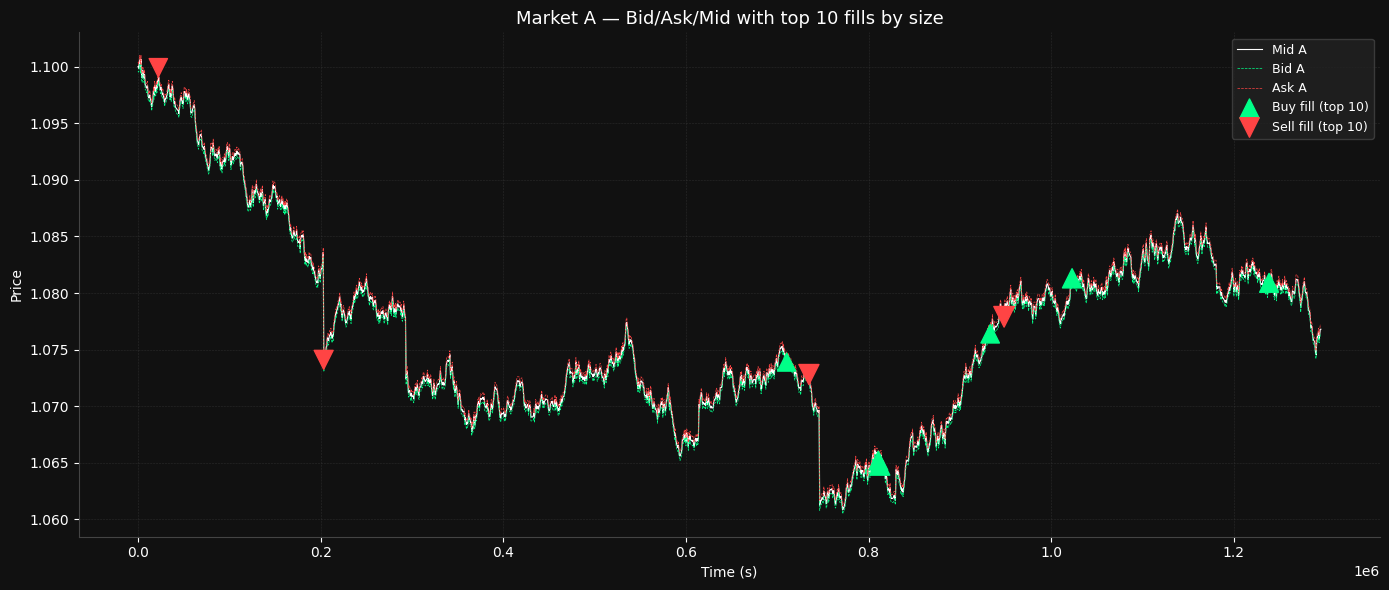

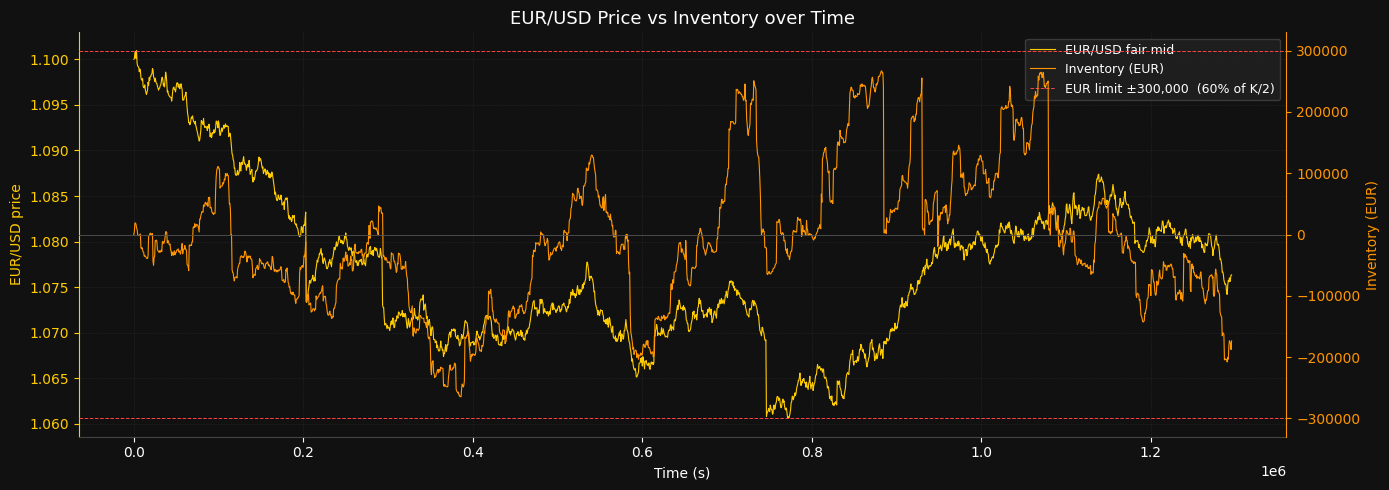

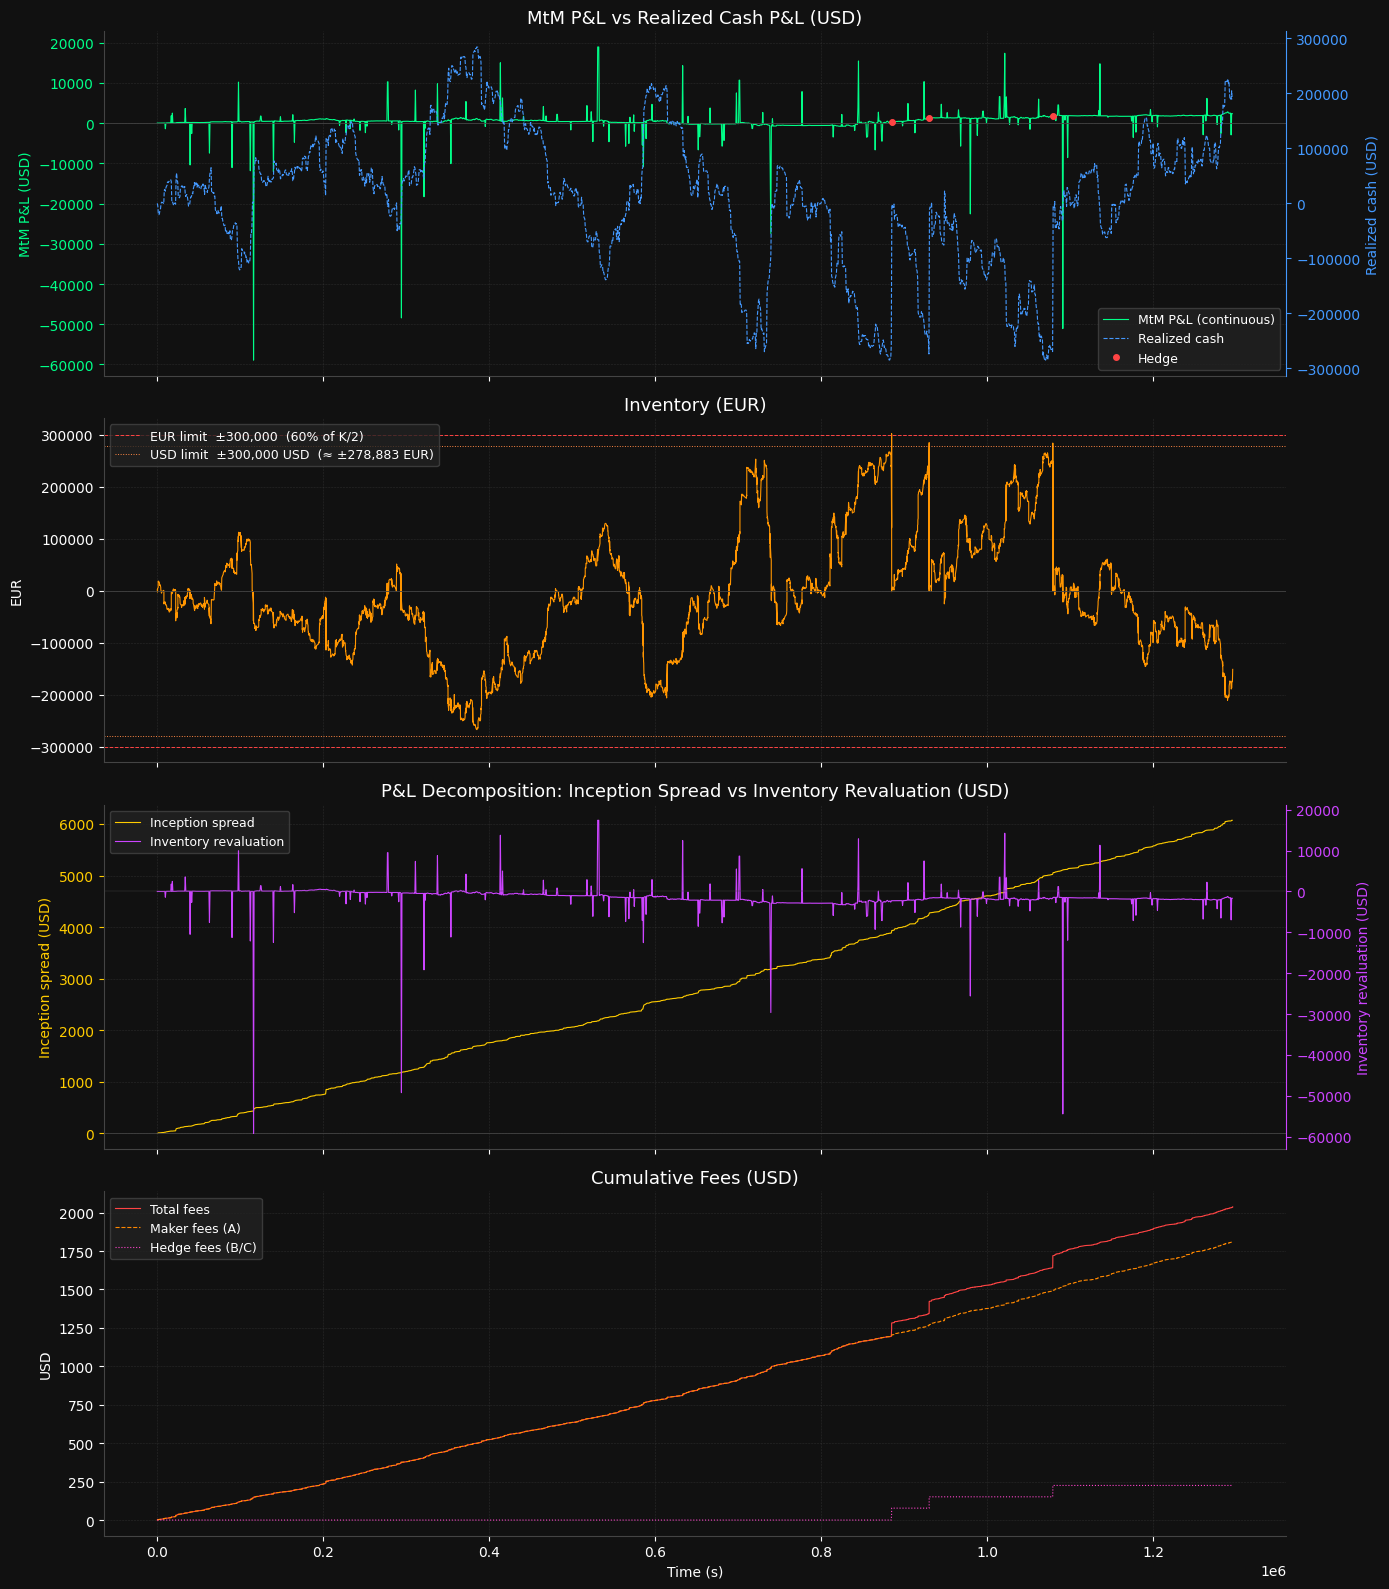

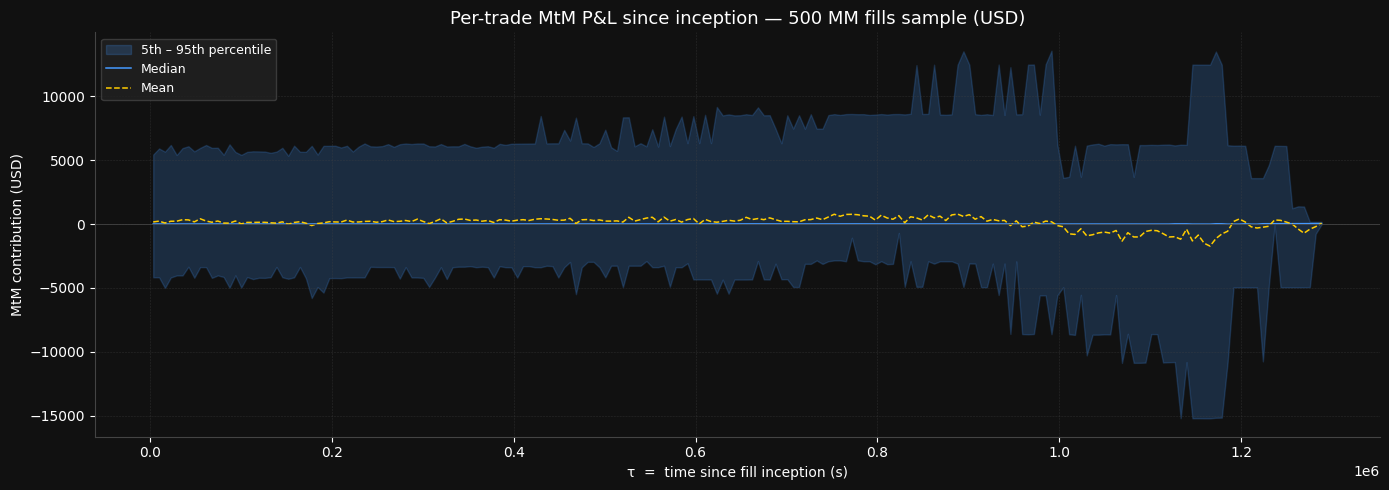

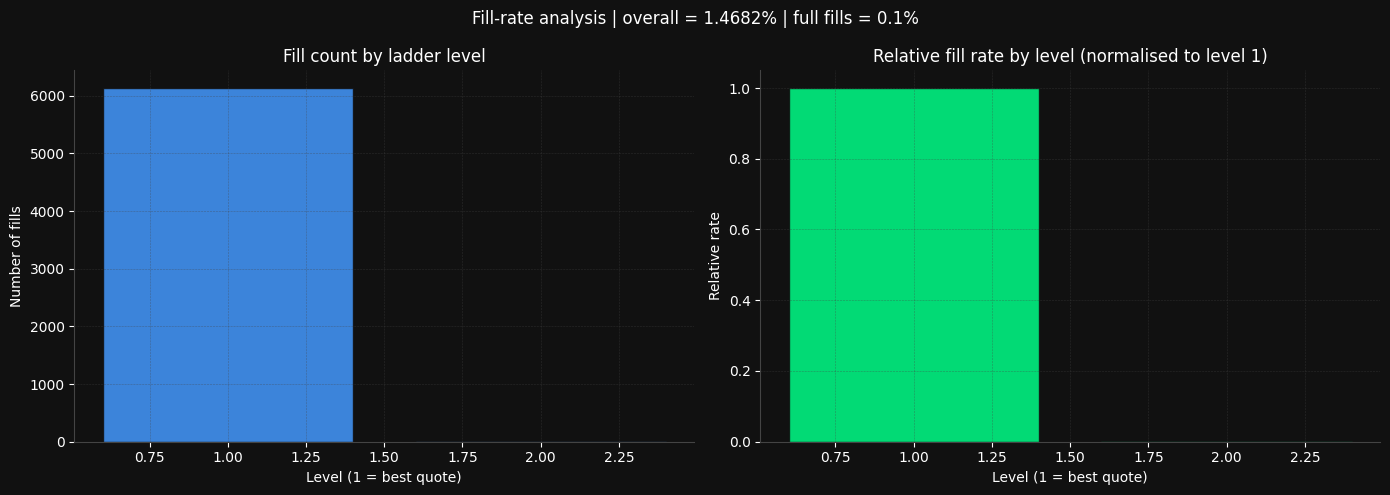

In [5]:
controller.report()

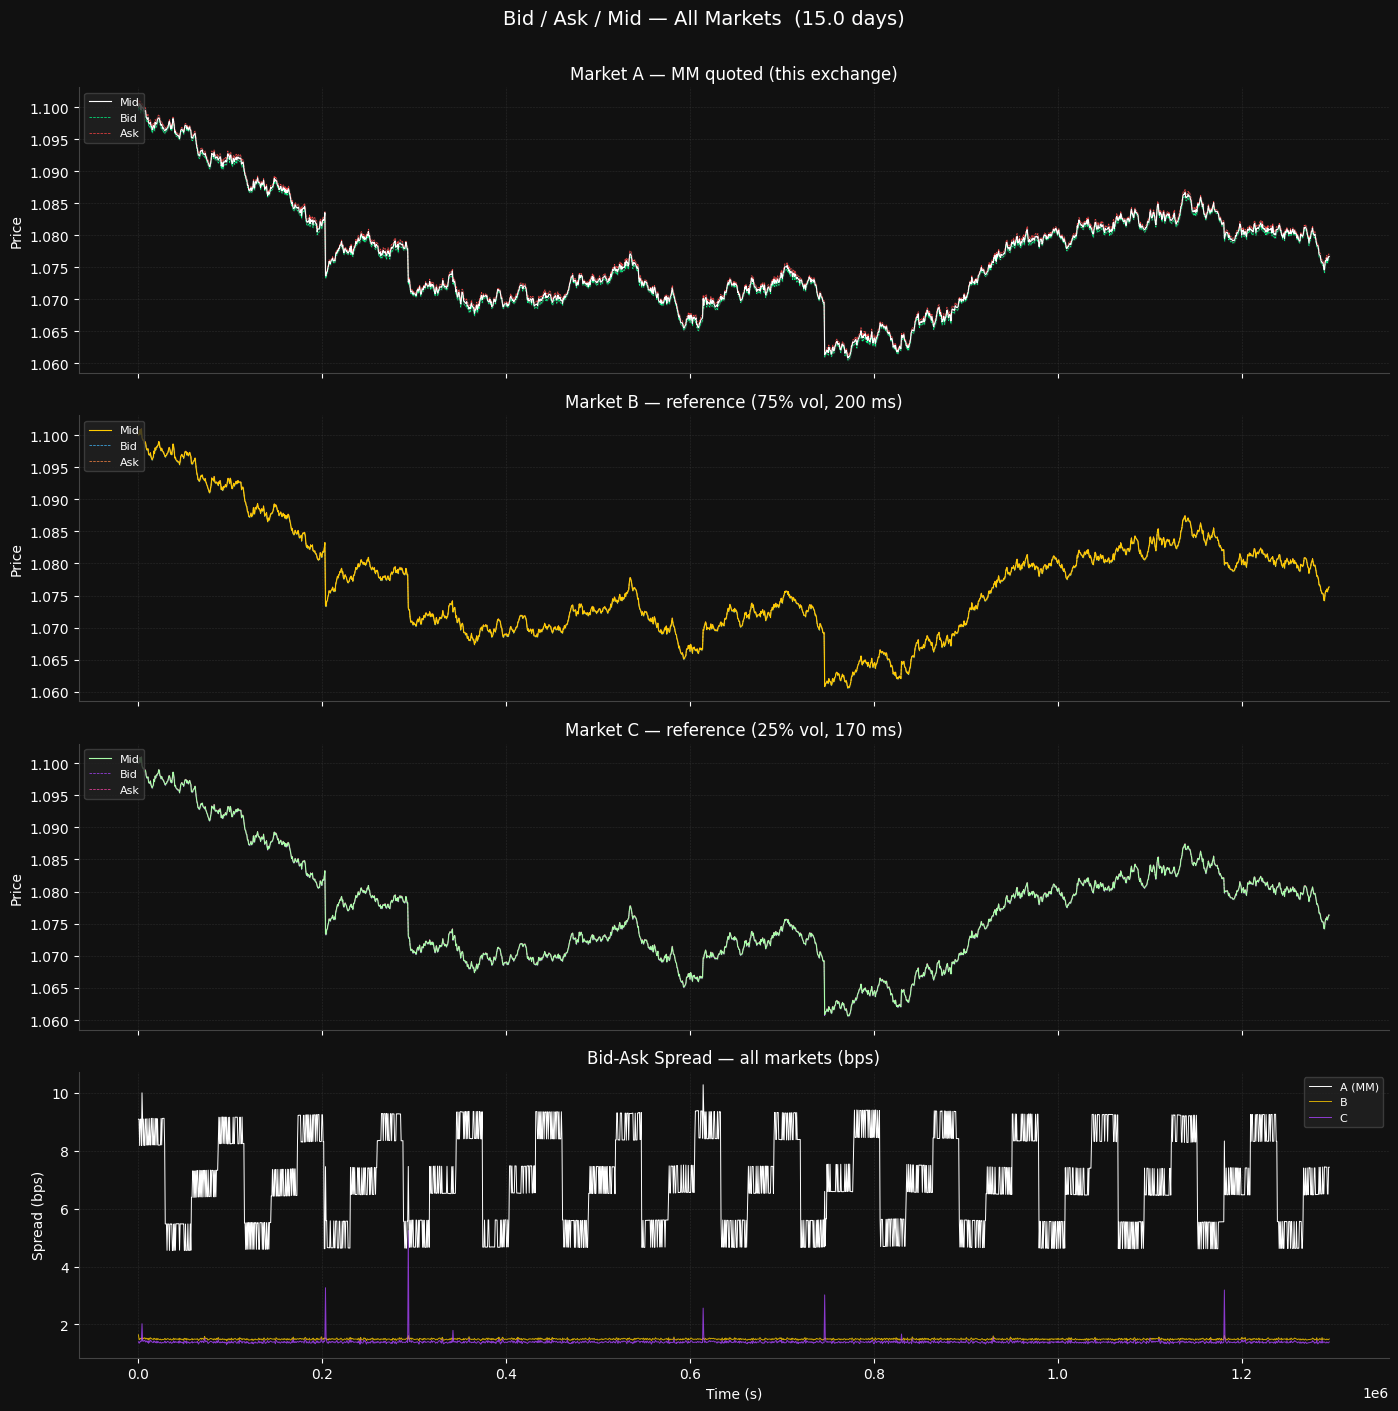

In [6]:
controller.plot_market_quotes()

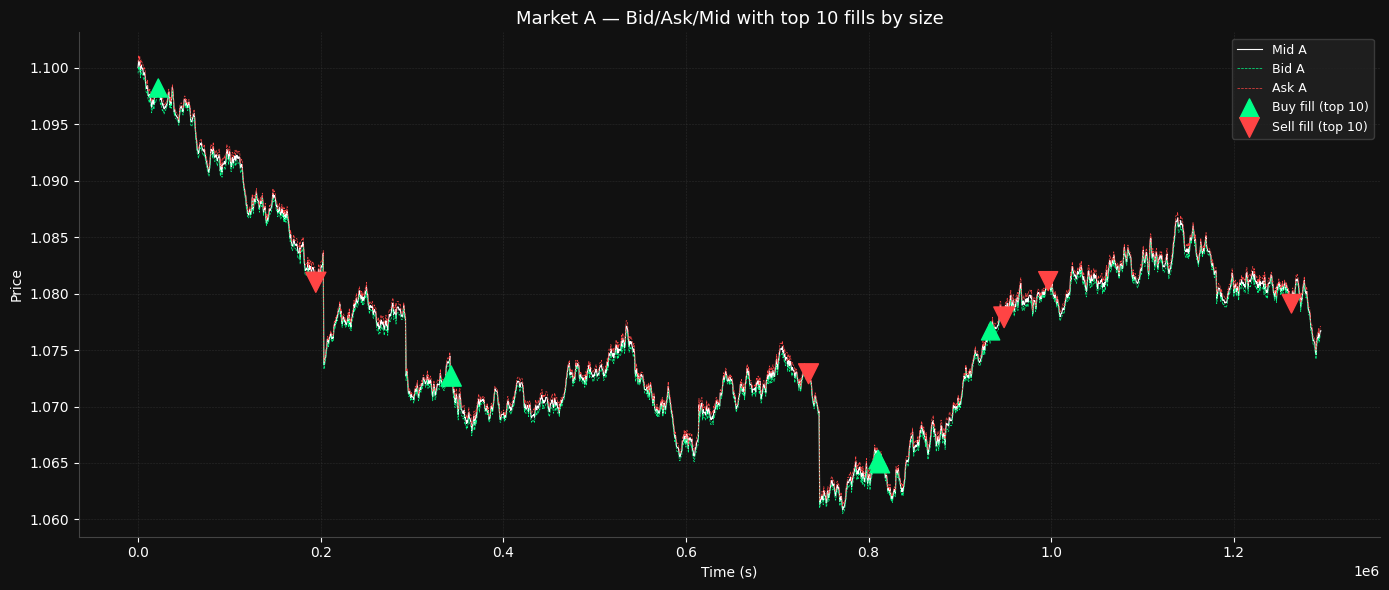

In [7]:
controller.plot_top_trades()

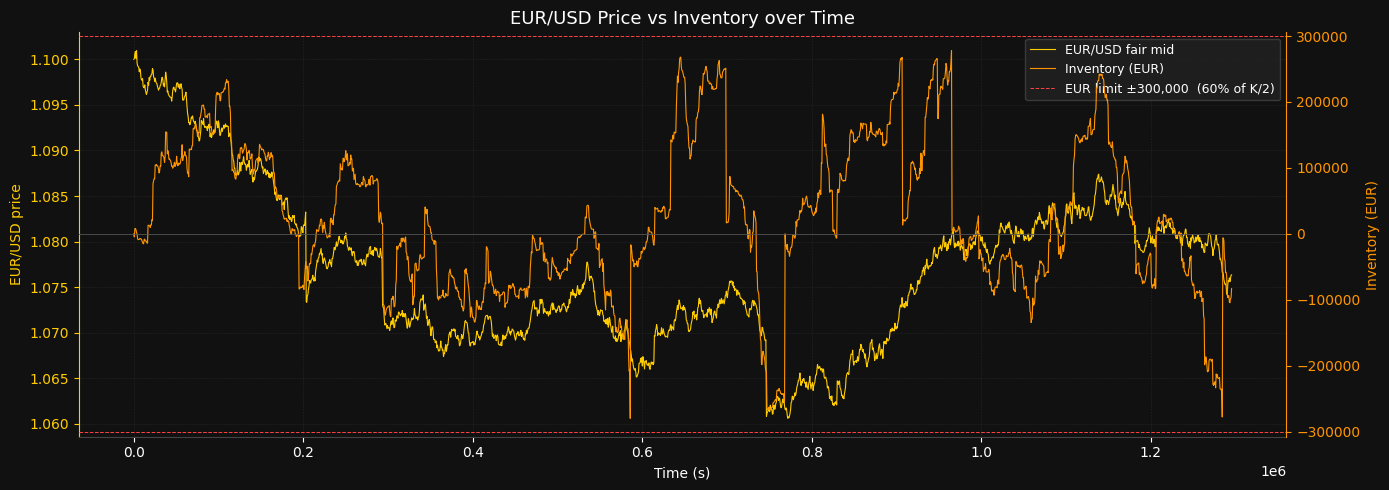

In [8]:
controller.plot_price_inventory()

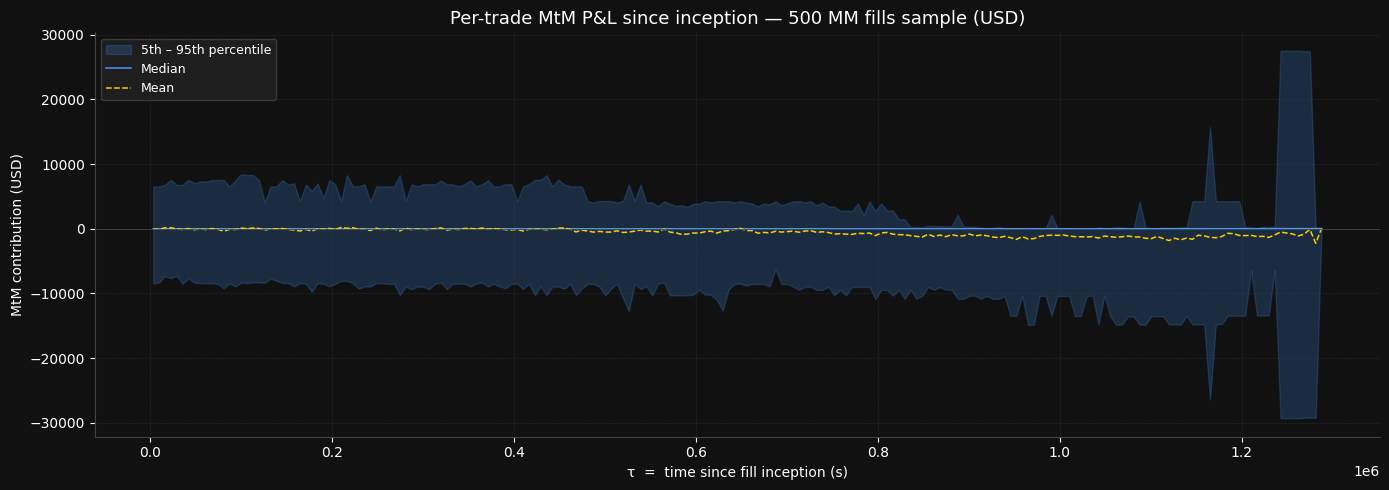

In [9]:
controller.plot_mtm_percentiles()

In [11]:
mask = controller.trade_history["level"] == 0
controller.trade_history[mask]

,order_id,level,step,t,direction,price,size,is_full_fill,fair_mid,fee_cost,cash_flow,inventory_after,is_hedge,is_eod_flat,venue
4102,NaN,0,17698238,884911.90,sell,1.068528,180935.78,True,1.06825,38.666976,193296.211481,1.213942e+05,True,False,B
4103,NaN,0,17698238,884911.90,sell,1.068540,121394.22,True,1.06825,38.914381,129675.690075,0.000000e+00,True,False,C
4324,NaN,0,18603300,930165.00,sell,1.076589,170502.43,True,1.07625,36.712208,183524.328343,1.145506e+05,True,False,B
4325,NaN,0,18603300,930165.00,sell,1.076591,114550.57,True,1.07625,36.997242,123287.142570,0.000000e+00,True,False,C
5049,NaN,0,21583739,1079186.95,sell,1.083266,169782.36,True,1.08295,36.783905,183882.741105,1.140896e+05,True,False,B
5050,NaN,0,21583739,1079186.95,sell,1.083271,114089.64,True,1.08295,37.077010,123552.957827,1.455192e-11,True,False,C


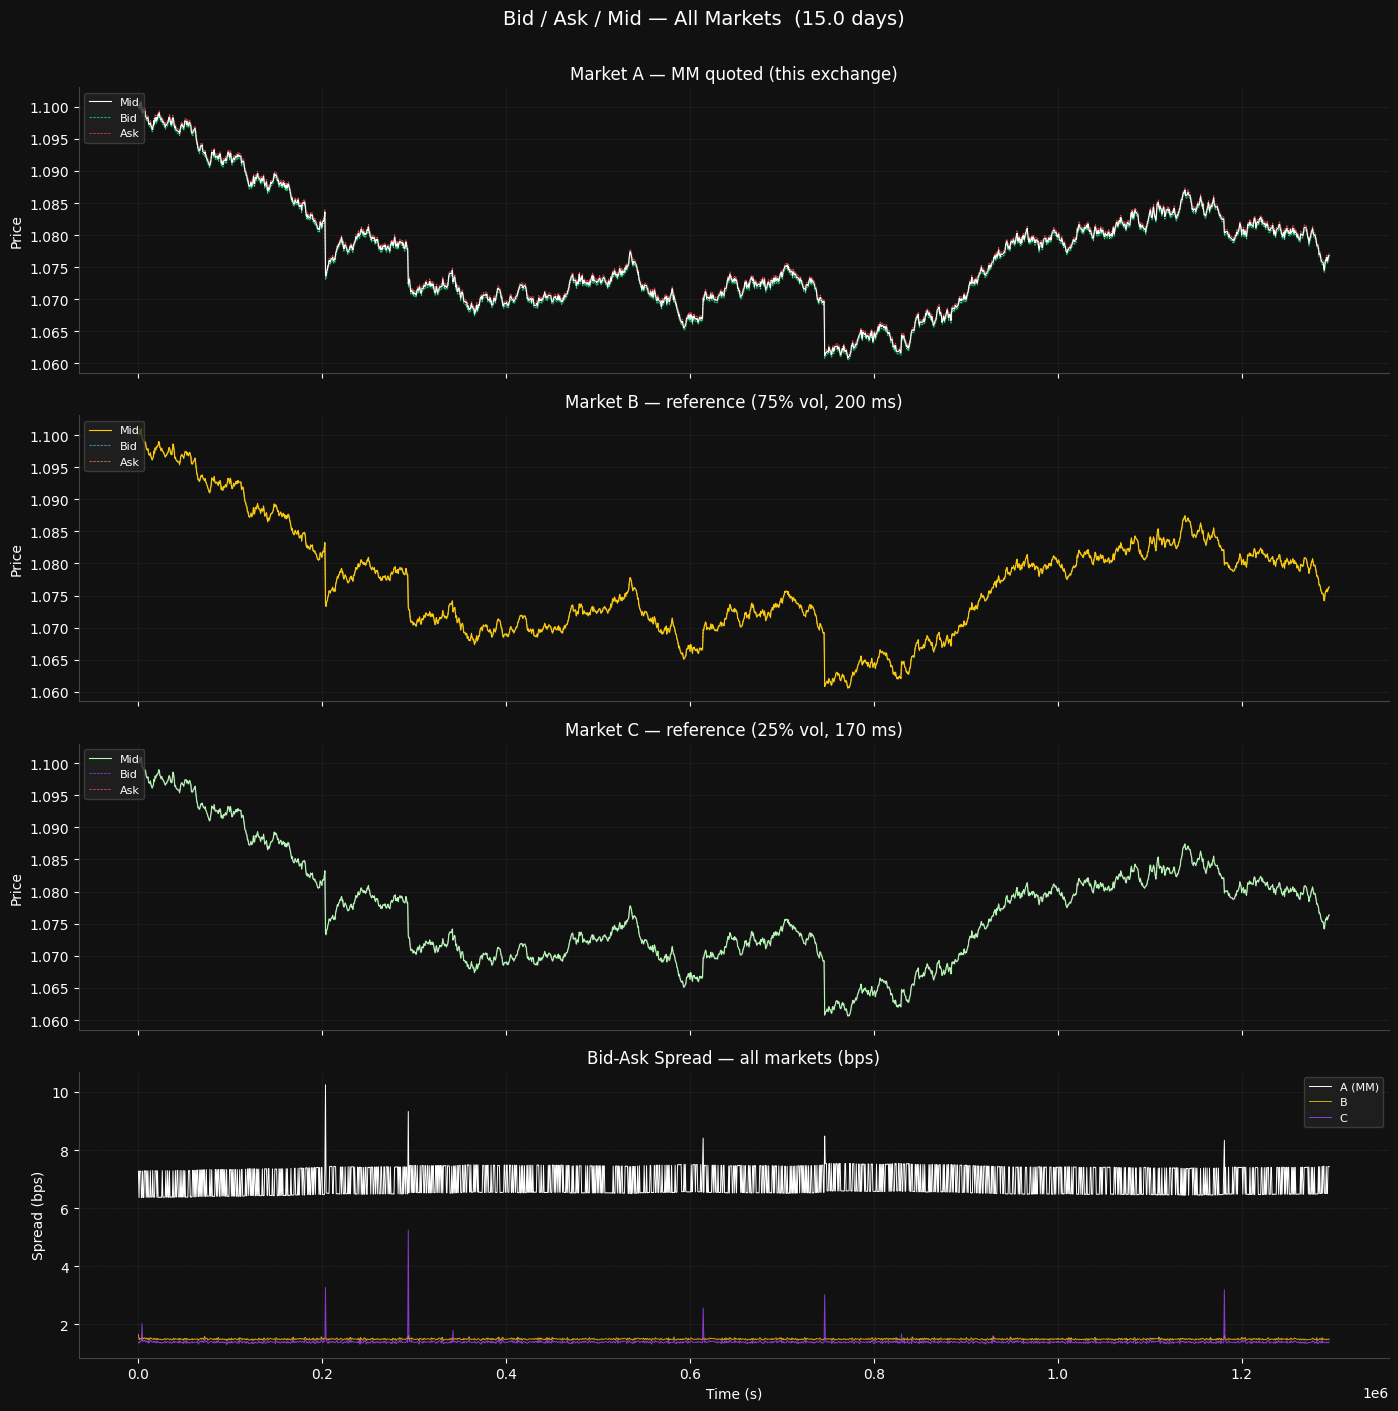

In [12]:
controller.plot_market_quotes()